In [3]:
%reload_ext autoreload
%autoreload 2

# import all the functions from the fastfeedback module
import iminuit
from fastfeedback import *
from tqdm import tqdm

# Loading the CAFs data

data_manager = DataManager("/storage/1/st15719/caf_new_sum_weighted.root")

# Defining the binning for the true and reco energy and coszenith
Ebins = np.logspace(-1, 1, 200)
Czbins = np.linspace(-1, 1, 100)
Ebins_reco = np.logspace(-1, 1, 50)
Czbins_reco = np.linspace(-1, 1, 20)

latex_names = {
    Flavor.NuE: r"$\nu_e$",
    Flavor.NuMu: r"$\nu_\mu$",
    Flavor.NuMuBar: r"$\bar{\nu}_\mu$",
    Flavor.NuEBar: r"$\bar{\nu}_e$",
    Flavor.NuTau: r"$\bar{\nu}_\tau$",
    Flavor.NuTauBar: r"$\bar{\nu}_\tau$",
}

Loading data...


/software/oz22897/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data


In [9]:
# Preparing the data with the default settings, of the current reco performances
def plot_data(method: int):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    null_hyps = [
        get_nufit(MH.Normal),
        get_nufit(MH.Normal),
        get_nufit(MH.Inverted),
        get_nufit(MH.Inverted),
    ]
    null_hyps[0].dcp = 0
    null_hyps[1].dcp = np.pi / 2
    null_hyps[2].dcp = 0
    null_hyps[3].dcp = np.pi / 2

    ref_event_rates = []

    for null_hyp in null_hyps:
        events.compute_osc(null_hyp)
        ref_event_rates.append(
            {fl: events.detected_events(fl) for fl in events.detected_channels}
        )

    LnL_values_nofit = [[] for _ in range(len(null_hyps))]
    dcp_scan = np.linspace(-np.pi, np.pi, 40)
    for dcp in dcp_scan:
        alt_hyp = get_nufit(MH.Normal)
        alt_hyp.dcp = dcp

        events.compute_osc(alt_hyp)

        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        for i, null_hyp in enumerate(null_hyps):
            # Computing the LnL values
            llh = 0
            for ch in events.detected_channels:
                llh += LnL(ref_event_rates[i][ch], expected[ch])
            LnL_values_nofit[i].append(llh)

    plt.figure()
    plt.plot(dcp_scan, LnL_values_nofit[0], label="NH, dcp=0")
    plt.plot(dcp_scan, LnL_values_nofit[1], label="NH, dcp=π/2")
    plt.plot(dcp_scan, LnL_values_nofit[2], label="IH, dcp=0")
    plt.plot(dcp_scan, LnL_values_nofit[3], label="IH, dcp=π/2")

    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    plt.title(
        f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}, Nu-Nubar={nunubar_disc.name}"
    )
    plt.legend()
    plt.show()


for i in tqdm(range(0b0000, 0b10000)):
    plot_data(i)

  0%|          | 0/16 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


  0%|          | 0/16 [00:16<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
#Plotting code for the individual flavors and their sum, with the possibility to select which flavors to plot and whether to plot the sum or not

def plot_data(method: int, flavors: dict[Flavor, int | float], plot_sum=True):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)

    efficiencies = {
        Flavor.NuE: flavors.get(Flavor.NuE, 1),
        Flavor.NuEBar: flavors.get(Flavor.NuEBar, 1),
        Flavor.NuMu: flavors.get(Flavor.NuMu, 1),
        Flavor.NuMuBar: flavors.get(Flavor.NuMuBar, 1),
        Flavor.NuTau: flavors.get(Flavor.NuTau, 1),
        Flavor.NuTauBar: flavors.get(Flavor.NuTauBar, 1),
        Flavor.NC: flavors.get(Flavor.NC, 1),
    }
    nunubar = FakeEfficiency(efficiencies)
    data_manager.set_nunubar_discrimination(Method.Efficiency, nunubar)
    data = data_manager.prepare_data()
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    sum = 0
    for ch, values in LnL_values.items():
        if ch not in flavors:
            continue

        if plot_sum:
            sum += values

        if len(flavors) == 1:
            plt.plot(
                sampling,
                values,
                label=f"{latex_names[ch]} Dir={direc_reco.name[0]}, E={energy_reco.name[0]}, Fl={flavor_disc.name[0]}",
            )
        else:
            plt.plot(sampling, values, label=latex_names[ch])

    if plot_sum:
        plt.plot(sampling, sum, label="Sum")
    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    if len(flavors) > 1:
        plt.title(
            f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}"
        )
    plt.legend()

In [ ]:
for i in tqdm(range(0b000, 0b1000)):
    plt.figure()
    plot_data(i, {Flavor.NuE: 1, Flavor.NuEBar: 1, Flavor.NuMu: 1, Flavor.NuMuBar: 1})
    plt.show()

In [ ]:
plt.figure()
for i in tqdm(range(0b000, 0b1000)):
    plot_data(i, {Flavor.NuE: 1}, False)
plt.show()

  0%|          | 0/16 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


  6%|▋         | 1/16 [00:54<13:42, 54.85s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


 12%|█▎        | 2/16 [01:37<11:05, 47.50s/it]

...

 88%|████████▊ | 14/16 [12:26<01:51, 55.87s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 94%|█████████▍| 15/16 [13:27<00:57, 57.50s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


100%|██████████| 16/16 [14:13<00:00, 53.34s/it]


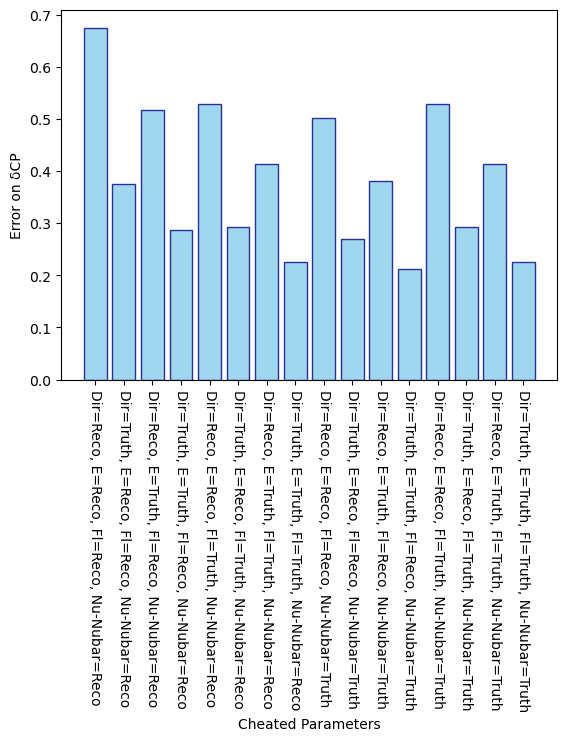

In [ ]:
results = []

def plot_data(method: int):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    def loss(dm21, dm31, th12, th13, th23, dcp):
        pars = ROOT.OscPars()
        pars.dm21 = dm21
        pars.dm31 = dm31
        pars.th12 = th12
        pars.th13 = th13
        pars.th23 = th23
        pars.dcp = dcp

        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}
        total_loss = 0
        for ch in events.detected_channels:
            total_loss += LnL(ref_event_rates[ch], expected[ch])
        # print(total_loss)
        return total_loss

    nufit = get_nufit(MH.Normal)

    fitter = iminuit.Minuit(
        loss,
        dm21=nufit.dm21,
        dm31=nufit.dm31,
        th12=nufit.th12,
        th13=nufit.th13,
        th23=nufit.th23,
        dcp=nufit.dcp,
    )

    dcp_err = fitter.hesse().errors["dcp"]
    best_fit_dcp = fitter.values["dcp"]

    results.append({
        "Method_ID": bin(method),
        "Direction": direc_reco.name,
        "Energy": energy_reco.name,
        "Flavor": flavor_disc.name,
        "Nu_Nubar": nunubar_disc.name,
        "dCP_BestFit": best_fit_dcp,
        "dCP_Error": dcp_err
    })


    plt.bar(
        f"Dir={direc_reco.name}, E={energy_reco.name}, Fl={flavor_disc.name}, Nu-Nubar={nunubar_disc.name}",
        dcp_err, color='skyblue', edgecolor='navy', alpha=0.8
    )
    plt.xticks(rotation=-90)


plt.figure()
plt.xlabel("Cheated Parameters")
plt.ylabel("Error on δCP")
for i in tqdm(range(0b0000, 0b10000)):
    plot_data(i)
plt.show()

In [ ]:
df = pd.DataFrame(results)
print("\n--- Delta CP Sensitivity Table ---")
print(df.to_string(index=False))
df


--- Delta CP Sensitivity Table ---
Method_ID Direction Energy Flavor Nu_Nubar  dCP_BestFit  dCP_Error
      0b0      Reco   Reco   Reco     Reco     5.340708   0.675380
      0b1     Truth   Reco   Reco     Reco     5.340708   0.375572
     0b10      Reco  Truth   Reco     Reco     5.340708   0.516572
     0b11     Truth  Truth   Reco     Reco     5.340708   0.286367
    0b100      Reco   Reco  Truth     Reco     5.340708   0.528940
    0b101     Truth   Reco  Truth     Reco     5.340708   0.293746
    0b110      Reco  Truth  Truth     Reco     5.340708   0.414362
    0b111     Truth  Truth  Truth     Reco     5.340708   0.225230
   0b1000      Reco   Reco   Reco    Truth     5.340708   0.501677
   0b1001     Truth   Reco   Reco    Truth     5.340708   0.269793
   0b1010      Reco  Truth   Reco    Truth     5.340708   0.380769
   0b1011     Truth  Truth   Reco    Truth     5.340708   0.212658
   0b1100      Reco   Reco  Truth    Truth     5.340708   0.528940
   0b1101     Truth   Reco

,Method_ID,Direction,Energy,Flavor,Nu_Nubar,dCP_BestFit,dCP_Error
0,0b0,Reco,Reco,Reco,Reco,5.340708,0.675380
1,0b1,Truth,Reco,Reco,Reco,5.340708,0.375572
2,0b10,Reco,Truth,Reco,Reco,5.340708,0.516572
3,0b11,Truth,Truth,Reco,Reco,5.340708,0.286367
4,0b100,Reco,Reco,Truth,Reco,5.340708,0.528940
5,0b101,Truth,Reco,Truth,Reco,5.340708,0.293746
6,0b110,Reco,Truth,Truth,Reco,5.340708,0.414362
7,0b111,Truth,Truth,Truth,Reco,5.340708,0.225230
8,0b1000,Reco,Reco,Reco,Truth,5.340708,0.501677
9,0b1001,Truth,Reco,Reco,Truth,5.340708,0.269793
